In [79]:
#Predicting Sequential Data With RNN
!pip install torch
import pandas as pd
from re import T
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

import torchvision.transforms as transforms

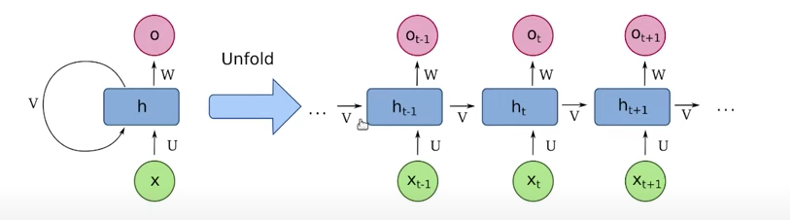

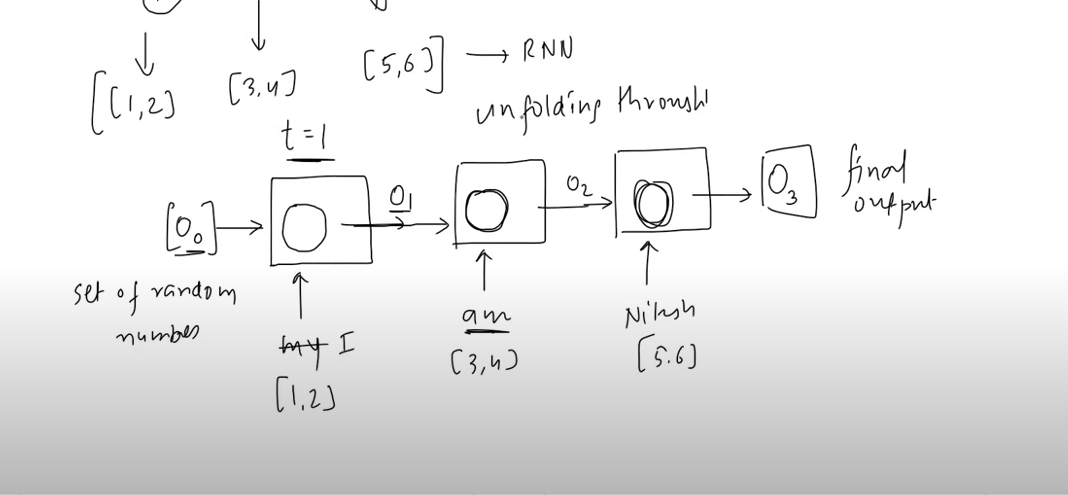

In [80]:
df = pd.read_csv("/content/100_Unique_QA_Dataset.csv")

In [81]:
df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [82]:
#TOKENIZATION -- Separting each word
#Vocab -- uniqque words
#covert word to numerical_indices


In [83]:

#TOKENIZATION
def tokenize(text):
  text =  text.lower()
  text =text.replace('?','')
  text = text.replace("'",'')

  return text.split()



In [84]:
vocab = {'<unk>':0 }  # if i get a word that is not there in my training text -- unknown


In [85]:
def build_vocab(row):

  tokenized_question = tokenize(row['question'])
  tokenized_answer = tokenize(row['answer'])

  merge_tokens = tokenized_question + tokenized_answer

  for token in merge_tokens:
    if token not in vocab:
      vocab[token] = len(vocab)


In [86]:
df.apply(build_vocab,axis=1)

,0
0,None
1,None
2,None
3,None
4,None
...,...
85,None
86,None
87,None
88,None


In [87]:
#coverting text to indices
def text_to_indices(text,vocab):
  indexed_text = []

  for token in tokenize(text):
    if token in vocab:
      indexed_text.append(vocab[token])
    else :
      indexed_text.append(vocab['<unk>'])

  return indexed_text


In [88]:
text_to_indices("is kanak",vocab)

[2, 0]

In [89]:
class QADataset(Dataset):

  def __init__(self,df,vocab):
    self.df  = df
    self.vocab = vocab


  def __len__(self):
    return self.df.shape[0]



  def __getitem__(self,index):
    numerical_question = text_to_indices(self.df.iloc[index]['question'],self.vocab)
    numerical_answer = text_to_indices(self.df.iloc[index]['answer'],self.vocab)

    return torch.tensor(numerical_question),torch.tensor(numerical_answer)




dataset  =QADataset(df,vocab)



In [90]:
dataset[2]

(tensor([10, 11, 12, 13, 14, 15]), tensor([16]))

In [91]:
dataloader = DataLoader(dataset,batch_size=1,shuffle=True)

In [92]:
for question ,answer in dataloader:
  print(question,answer)

tensor([[  1,   2,   3, 103,   5, 104,  19, 105]]) tensor([[106]])
tensor([[  1,   2,   3,   4,   5, 135]]) tensor([[136]])
tensor([[ 42,   2,   3, 274, 211, 275]]) tensor([[276]])
tensor([[ 10,  11, 189, 158, 190]]) tensor([[191]])
tensor([[ 1,  2,  3, 24, 25,  5, 26, 19, 27]]) tensor([[28]])
tensor([[ 10, 308,   3, 309, 310]]) tensor([[311]])
tensor([[ 42, 137,   2, 138,  39, 139]]) tensor([[53]])
tensor([[ 42, 318,   2,  62,  63,   3, 319,   5, 320]]) tensor([[321]])
tensor([[  1,   2,   3, 221,   5, 222, 223, 224]]) tensor([[225]])
tensor([[ 42, 250, 251, 118, 252, 253]]) tensor([[254]])
tensor([[10, 29,  3, 30, 31]]) tensor([[32]])
tensor([[ 42, 200,   2,  14, 201, 202, 203, 204]]) tensor([[205]])
tensor([[1, 2, 3, 4, 5, 6]]) tensor([[7]])
tensor([[ 1,  2,  3, 33, 34,  5, 35]]) tensor([[36]])
tensor([[ 42, 125,   2,  62,  63,   3, 126, 127]]) tensor([[128]])
tensor([[  1,   2,   3, 163, 164, 165,  83,  84]]) tensor([[166]])
tensor([[ 78,  79, 150, 151,  14, 152, 153]]) tensor([[15

In [93]:
#RNN ARCHITECTURE

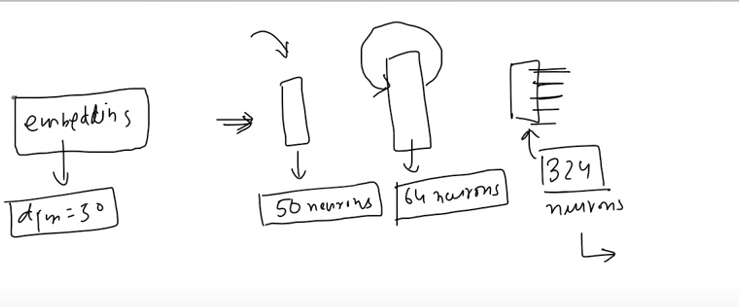

In [94]:
class SIMPLERNN(nn.Module):

  def __init__(self,vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size,embedding_dim=50)
    self.rnn = nn.RNN(50,64,batch_first = True)
    self.fc = nn.Linear(64,vocab_size)





  def forward(self,question):
    embedded_question = self.embedding(question)
    hidden,final = self.rnn(embedded_question)

    output = self.fc(final.squeeze(0))

    return output




In [95]:
learning_rate = 0.001
epochs = 20

In [96]:
model = SIMPLERNN(len(vocab))
criterion  = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = learning_rate)


In [97]:
#trainingloop
for epoch in range(epochs):


  total_loss =0


  for question,answer in dataloader:


    optimizer.zero_grad()

    #forwardpass

    output = model(question)

    #loss

    loss = criterion(output, answer[0])

    #gradients

    loss.backward()

    optimizer.step()

    total_loss = total_loss +loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss:4f}")









Epoch 1, Loss: 520.817069
Epoch 2, Loss: 450.062305
Epoch 3, Loss: 371.286636
Epoch 4, Loss: 312.232327
Epoch 5, Loss: 261.521499
Epoch 6, Loss: 213.065630
Epoch 7, Loss: 170.204453
Epoch 8, Loss: 132.022286
Epoch 9, Loss: 101.423143
Epoch 10, Loss: 77.047034
Epoch 11, Loss: 59.141268
Epoch 12, Loss: 45.866453
Epoch 13, Loss: 36.313223
Epoch 14, Loss: 28.894129
Epoch 15, Loss: 23.298740
Epoch 16, Loss: 19.369661
Epoch 17, Loss: 16.135517
Epoch 18, Loss: 13.667827
Epoch 19, Loss: 11.734237
Epoch 20, Loss: 10.161525


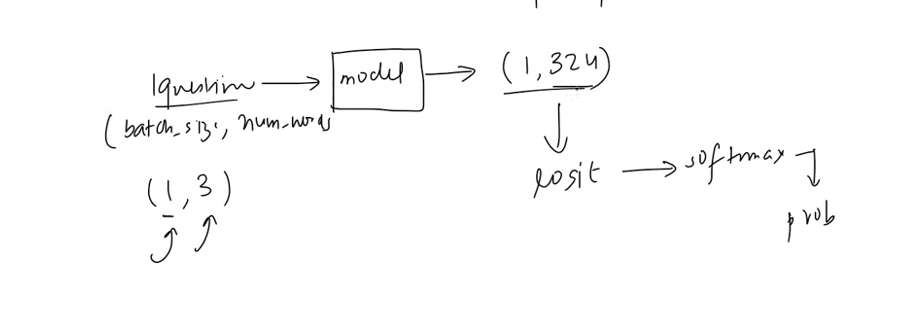

In [109]:
def predict(model, question, threshold=0.5):

  # convert question to numbers
  numerical_question = text_to_indices(question, vocab)

  # tensor
  question_tensor = torch.tensor(numerical_question).unsqueeze(0)

  # send to model
  output = model(question_tensor)

  # convert logits to probs
  probs = torch.nn.functional.softmax(output, dim=1)

  # find index of max prob
  value, index = torch.max(probs, dim=1)

  if value < threshold:
    print("I don't know")

  print(list(vocab.keys())[index])

In [113]:
predict(model, "  Which gas do plants use for photosynthesis?")

co2


'alexander-fleming'